In [5]:
pip install geopandas

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ------------- -------------------------- 7.6/22.9 MB 37.5 MB/s eta 0:00:01
   ------------------------------- -------- 18.1/22.9 MB 44.4 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 40.8 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 40.3 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 20.9 MB/s  0:00:00

   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------- ----------------------------- 1/4 [pyproj]
   ---------- ----------------------------- 1/4 [pyproj]
   -------------------- ------------------- 2/4 [pyogrio]
   -------------------- ------------------- 2/4 [pyogrio]
   ---

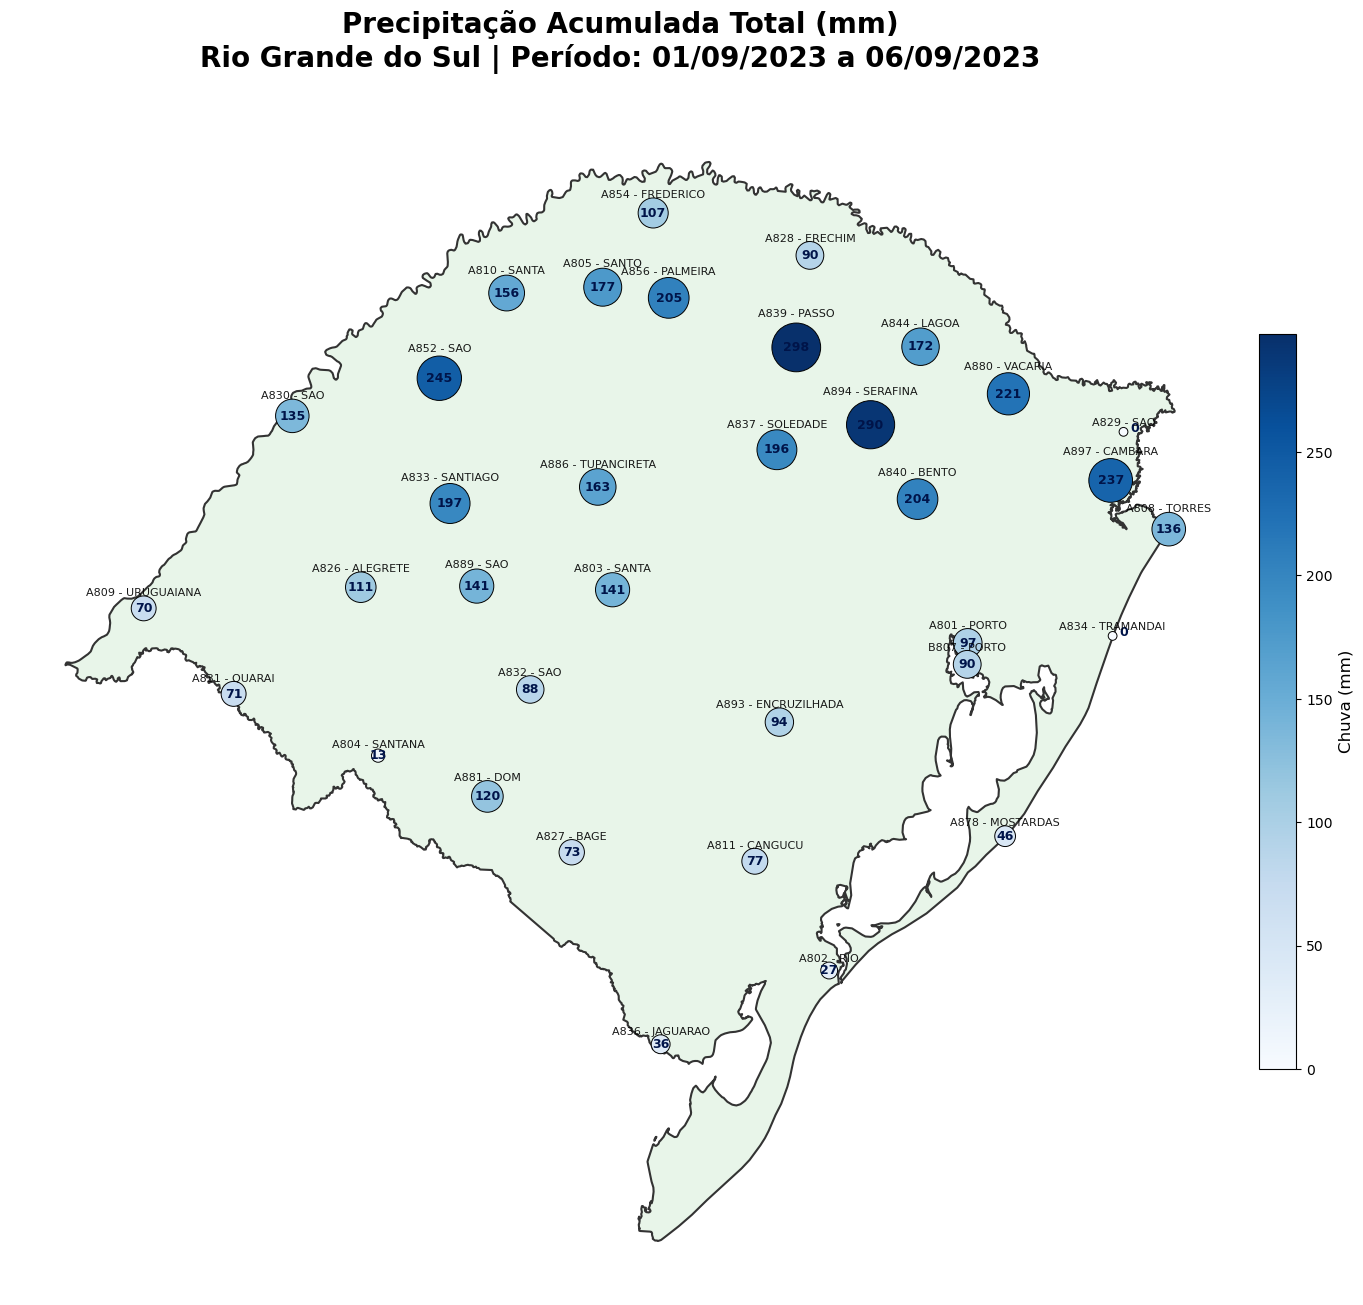

In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import glob

arquivos = glob.glob("dados_*.csv")
lista_estacoes = []

for arquivo in arquivos:
    try:
        sigla_estacao = arquivo.split('_')[1] if '_' in arquivo else "S/C"

        meta = {'lat': None, 'lon': None, 'nome': 'Desconhecida'}
        with open(arquivo, 'r', encoding='latin1') as f:
            for _ in range(12):
                linha = next(f)
                if 'Nome:' in linha: meta['nome'] = linha.split(':')[1].strip()
                if 'Latitude:' in linha: meta['lat'] = float(linha.split(':')[1].replace(',', '.'))
                if 'Longitude:' in linha: meta['lon'] = float(linha.split(':')[1].replace(',', '.'))

        df_temp = pd.read_csv(arquivo, sep=';', skiprows=10, encoding='latin1', decimal=',', engine='python')
        col_chuva = [c for c in df_temp.columns if 'PRECIPITACAO' in c]

        if col_chuva and meta['lat'] is not None:
            total_chuva = df_temp[col_chuva[0]].fillna(0).sum()
            lista_estacoes.append({
                'Sigla': sigla_estacao,
                'Nome': meta['nome'],
                'Latitude': meta['lat'],
                'Longitude': meta['lon'],
                'Chuva': total_chuva
            })
    except Exception as e:
        print(f"Erro no arquivo {arquivo}: {e}")

df_estacoes = pd.DataFrame(lista_estacoes)

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url)
rs_mapa = brasil[brasil['sigla'] == 'RS']

fig, ax = plt.subplots(figsize=(15, 15))

rs_mapa.plot(ax=ax, facecolor='#E8F5E9', edgecolor='#333333', linewidth=1.5, zorder=1)

if not df_estacoes.empty:
    bolotas = ax.scatter(
        df_estacoes['Longitude'],
        df_estacoes['Latitude'],
        s=df_estacoes['Chuva'] * 4 + 40,
        c=df_estacoes['Chuva'],
        cmap='Blues',
        alpha=1.0,
        edgecolors='black',
        linewidth=0.7,
        zorder=3
    )

    for _, row in df_estacoes.iterrows():
        chuva = row['Chuva']

        if chuva < 10:
            ax.text(row['Longitude'] + 0.05, row['Latitude'], f"{chuva:.0f}",
                    fontsize=9, ha='left', fontweight='bold', color='#001449')
        else:
            ax.text(row['Longitude'], row['Latitude'], f"{chuva:.0f}",
                    fontsize=9, ha='center', va='center', fontweight='bold', color='#001449')

        offset_y = 0.04 + (chuva/100) * 0.05
        label = f"{row['Sigla']} - {row['Nome'].split()[0]}"

        ax.text(row['Longitude'], row['Latitude'] + offset_y, label,
                fontsize=8, ha='center', color='black', alpha=0.9)

ax.set_title(
    'Precipitação Acumulada Total (mm)\nRio Grande do Sul | Período: 01/09/2023 a 06/09/2023',
    fontsize=20, fontweight='bold',
    bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.8, 'pad': 10},
    pad=30
)

cbar = plt.colorbar(bolotas, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Chuva (mm)', fontsize=12)

ax.axis('off')
plt.tight_layout()
plt.show()